# BoxPlot

In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
def clean_list (skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
df['job_skills'] = df['job_skills'].apply(clean_list)

In [2]:
df_da_us = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

In [3]:
df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

In [4]:
df_da_us['salary_year_avg'].sample(10)

281200     98500.0
784882     87500.0
212049     95298.5
314960     67500.0
723097     77500.0
381254     70000.0
148122     90000.0
727016    120000.0
751611     52500.0
656032    100000.0
Name: salary_year_avg, dtype: float64

<Axes: >

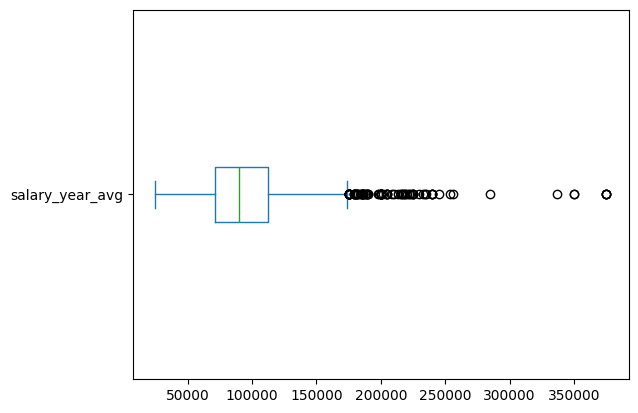

In [5]:
df_da_us['salary_year_avg'].plot(kind='box', vert = False)

C:\Users\jhonn\AppData\Local\Temp\ipykernel_13544\2335858468.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert = False)


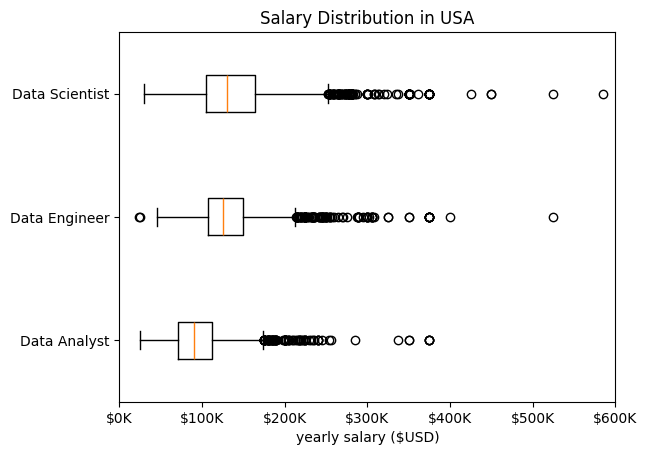

In [18]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country']=='United States')].copy()

df_us = df_us.dropna(subset=['salary_year_avg'])

job_list = [ df_us[df_us['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert = False)
plt.title('Salary Distribution in USA')
plt.xlabel('yearly salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()